In [1]:
!git clone https://github.com/quark28/miniml.git
%cd miniml

Cloning into 'miniml'...
remote: Enumerating objects: 155, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (114/114), done.
remote: Total 155 (delta 76), reused 115 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (155/155), 919.81 KiB | 8.76 MiB/s, done.
Resolving deltas: 100% (76/76), done.
/content/miniml


In [19]:
# %% [Cell 1] — Установка и импорты
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from svm import SVM

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)

In [30]:
# %% [Cell 2] — Датасет 1: 2D-синтетика для визуализации границ и margin
X_synth, y_synth = make_classification(
    n_samples=300, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.5, random_state=42
)
y_synth_pm = np.where(y_synth == 0, -1, 1)
Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_synth, y_synth_pm, test_size=0.3, random_state=42)

In [31]:
# %% [Cell 3] — Датасет 2: breast cancer (реальные данные, многомерные)
X_bc, y_bc = load_breast_cancer(return_X_y=True)
X_bc = StandardScaler().fit_transform(X_bc)
y_bc_pm = np.where(y_bc == 0, -1, 1)

Xbc_train, Xbc_test, ybc_train, ybc_test = train_test_split(X_bc, y_bc_pm, test_size=0.3, random_state=42)
ybc_train_01 = np.where(ybc_train == -1, 0, 1)
ybc_test_01 = np.where(ybc_test == -1, 0, 1)

In [32]:
# %% [Cell 4] — Обучение своей SVM и sklearn LinearSVC на breast cancer
my_svm = SVM(kernel='linear', const=1.0)
my_svm.fit(Xbc_train, ybc_train, learning_type='gd', n_steps=3000, lr=0.05, lr_type='constant')
my_pred = my_svm.predict(Xbc_test)
my_acc = accuracy_score(ybc_test, my_pred)

sk_svm = LinearSVC(C=1.0, max_iter=5000)
sk_svm.fit(Xbc_train, ybc_train_01)
sk_pred_01 = sk_svm.predict(Xbc_test)
sk_acc = accuracy_score(ybc_test_01, sk_pred_01)

print(f"Breast cancer — своя SVM accuracy:    {my_acc:.4f}")
print(f"Breast cancer — sklearn LinearSVC:    {sk_acc:.4f}")

Breast cancer — своя SVM accuracy:    0.9591
Breast cancer — sklearn LinearSVC:    0.9766


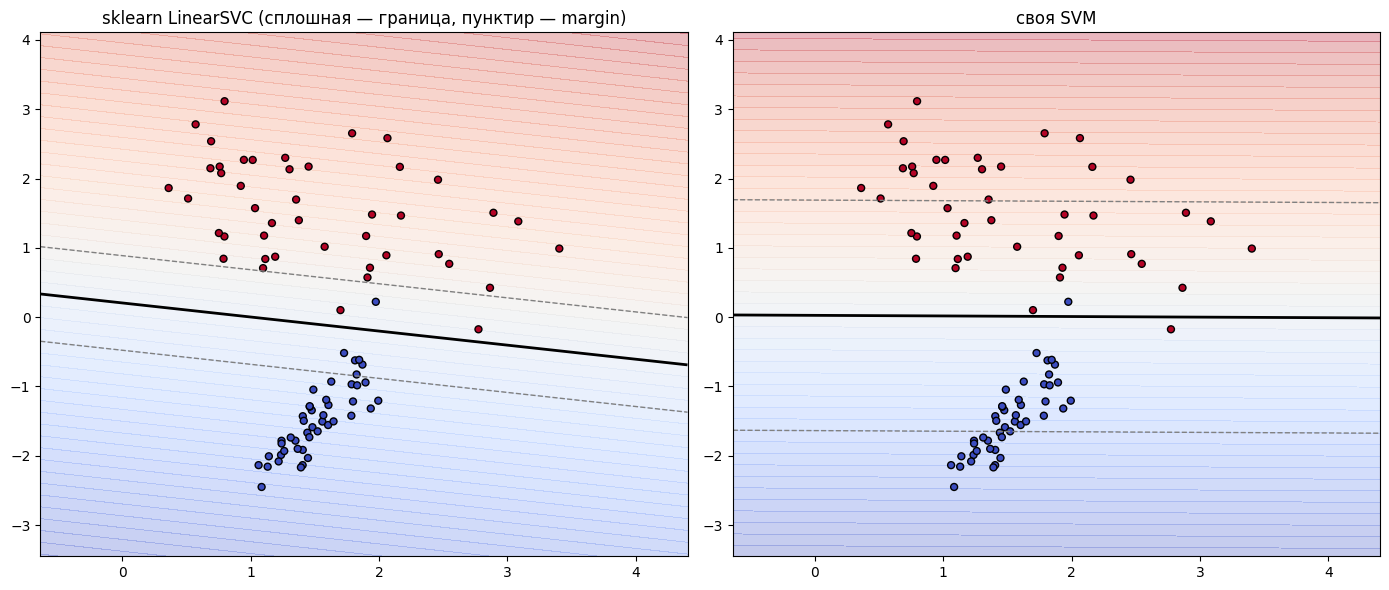

In [33]:
# %% [Cell 5] — Визуализация границы решений + margin на 2D-синтетике
def plot_svm_boundary(model, X, y, ax, title, is_sklearn=False):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]

    if is_sklearn:
        Z = model.decision_function(grid)
    else:
        grid_bias = np.c_[grid, np.ones(grid.shape[0])]
        Z = grid_bias @ model.w
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=50, alpha=0.3, cmap='coolwarm')
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors=['gray', 'black', 'gray'],
               linestyles=['--', '-', '--'], linewidths=[1, 2, 1])
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=25)
    ax.set_title(title)


my_svm_synth = SVM(kernel='linear', const=1.0)
my_svm_synth.fit(Xs_train, ys_train, learning_type='gd', n_steps=2000, lr=0.05, lr_type='constant')

ys_train_01 = np.where(ys_train == -1, 0, 1)
sk_svm_synth = LinearSVC(C=1.0, max_iter=5000)
sk_svm_synth.fit(Xs_train, ys_train_01)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_svm_boundary(sk_svm_synth, Xs_test, ys_test, axes[0], 'sklearn LinearSVC (сплошная — граница, пунктир — margin)', is_sklearn=True)
plot_svm_boundary(my_svm_synth, Xs_test, ys_test, axes[1], 'своя SVM')
plt.tight_layout()
plt.savefig('svm_decision_boundary.png', dpi=100)
plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/content/miniml/svm.py:19: RuntimeWarning: overflow encountered in multiply
  result =  1/self.C * w
/content/miniml/linear_classification.py:180: RuntimeWarning: invalid value encountered in subtract
  self.w = self.w - lr * self._compute_gradient(X_with_bias, y)


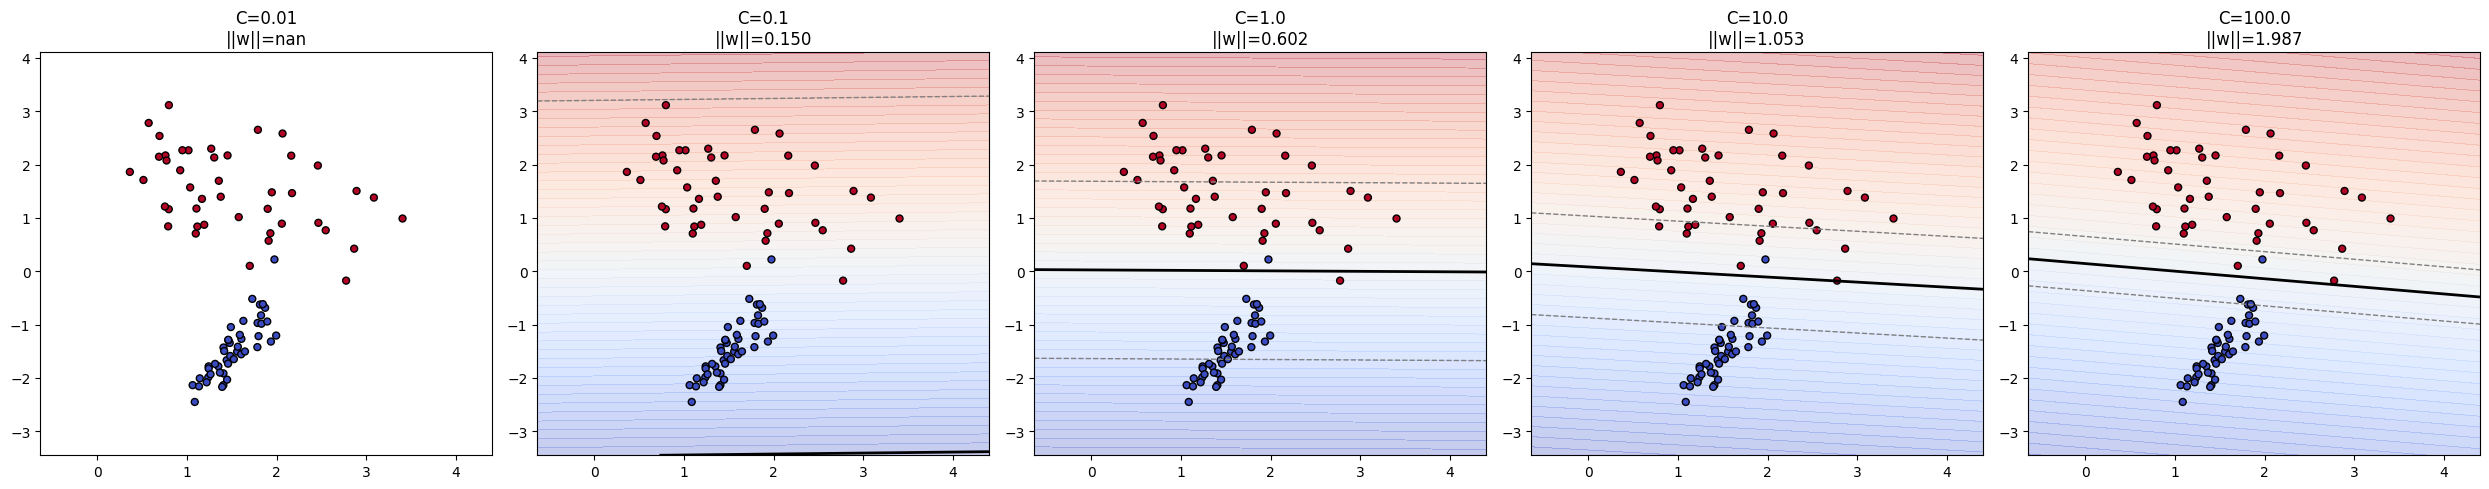

Норма весов по C: {0.01: np.float64(nan), 0.1: np.float64(0.14998790964314293), 1.0: np.float64(0.6015711098297483), 10.0: np.float64(1.0531551342078806), 100.0: np.float64(1.9872587713820709)}
Ожидается рост ||w|| с увеличением C (меньше регуляризации -> более узкий/жёсткий margin).


In [34]:
# %% [Cell 6] — Влияние параметра C на норму весов и границу решений
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]
norms = []

fig, axes = plt.subplots(1, len(C_values), figsize=(5 * len(C_values), 5))
for ax, C in zip(axes, C_values):
    m = SVM(kernel='linear', const=C)
    m.fit(Xs_train, ys_train, learning_type='gd', n_steps=2000, lr=0.05, lr_type='constant')
    norms.append(np.linalg.norm(m.coefficients))
    plot_svm_boundary(m, Xs_test, ys_test, ax, f'C={C}\n||w||={np.linalg.norm(m.coefficients):.3f}')

plt.tight_layout()
plt.savefig('svm_C_effect.png', dpi=100)
plt.show()

print("Норма весов по C:", dict(zip(C_values, norms)))
print("Ожидается рост ||w|| с увеличением C (меньше регуляризации -> более узкий/жёсткий margin).")

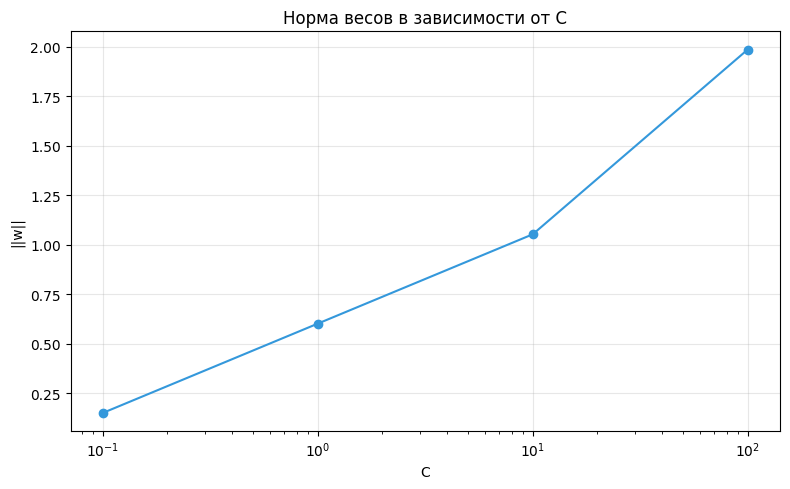

In [35]:
# %% [Cell 7] — График: ||w|| в зависимости от C (log-scale по X)
plt.figure(figsize=(8, 5))
plt.semilogx(C_values, norms, marker='o', color='#3498db')
plt.xlabel('C')
plt.ylabel('||w||')
plt.title('Норма весов в зависимости от C')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('svm_norm_vs_C.png', dpi=100)
plt.show()

     C  my_accuracy  sklearn_accuracy
  0.01     0.631579          0.994152
  0.10     0.836257          0.982456
  1.00     0.959064          0.976608
 10.00     0.988304          0.959064
100.00     0.976608          0.935673


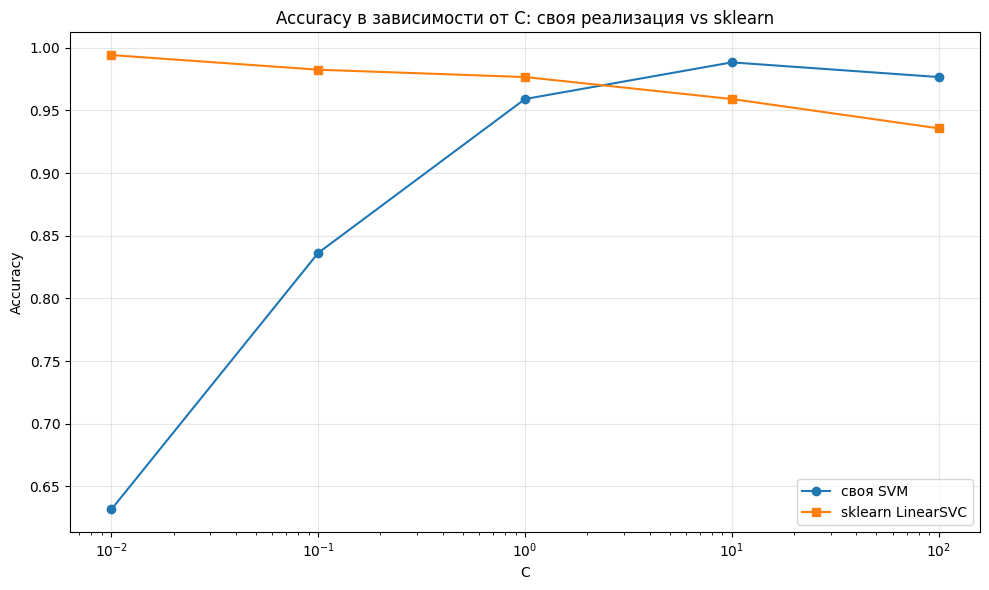

In [43]:
# %% [Cell 8] — Сравнение accuracy: своя SVM vs sklearn на разных C
comparison = []
for C in C_values:
    m = SVM(kernel='linear', const=C)
    lr_for_C = 0.01
    m.fit(Xbc_train, ybc_train, learning_type='gd', n_steps=3000, lr=lr_for_C, lr_type='constant')
    p = m.predict(Xbc_test)
    a = accuracy_score(ybc_test, p)

    sk = LinearSVC(C=C, max_iter=5000)
    sk.fit(Xbc_train, ybc_train_01)
    sk_p = sk.predict(Xbc_test)
    sk_a = accuracy_score(ybc_test_01, sk_p)

    comparison.append((C, a, sk_a))

df_comp = pd.DataFrame(comparison, columns=['C', 'my_accuracy', 'sklearn_accuracy'])
print(df_comp.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.semilogx(df_comp['C'], df_comp['my_accuracy'], marker='o', label='своя SVM')
plt.semilogx(df_comp['C'], df_comp['sklearn_accuracy'], marker='s', label='sklearn LinearSVC')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title('Accuracy в зависимости от C: своя реализация vs sklearn')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('svm_accuracy_vs_C.png', dpi=100)
plt.show()

In [37]:
# %% [Cell 9] — Проверка нереализованных ядер
for kernel in ['poly', 'rbf', 'tanh']:
    try:
        SVM(kernel=kernel)
        print(f"kernel='{kernel}': ОШИБКА — должно было бросить исключение")
    except NotImplementedError as e:
        print(f"kernel='{kernel}': корректно бросает NotImplementedError ({e})")
    except Exception as e:
        print(f"kernel='{kernel}': бросает {type(e).__name__} вместо NotImplementedError — нужно исправить")

kernel='poly': корректно бросает NotImplementedError (poly kernel not implemented yet)
kernel='rbf': корректно бросает NotImplementedError (rbf kernel not implemented yet)
kernel='tanh': корректно бросает NotImplementedError (tanh kernel not implemented yet)


In [38]:
# %% [Cell 10] — Итог
print("=" * 60)
print("ИТОГ")
print("=" * 60)
print(df_comp.to_string(index=False))

ИТОГ
     C  my_accuracy  sklearn_accuracy
  0.01     0.654971          0.994152
  0.10     0.654971          0.982456
  1.00     0.906433          0.976608
 10.00     0.935673          0.959064
100.00     0.871345          0.935673
